In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import pypsa
import xlsxwriter
import tz_pypsa
import tz_pypsa.wrangle as wrangle
import pandas as pd
# import tz_solve
import plotly.express as px
import plotly.graph_objects as go
from tz_pypsa.model import Model
from tz_pypsa.utils import get_examples
import os
import glob

In [40]:
n = pypsa.Network()
n.import_from_netcdf("C:/Users/jy/TransitionZero/Google - CFE - Documents/04. Country Specific Vault/Japan/02. Data & Results/Outputs/1_Diagnosis/TP2/JPN_P2_JPN09/solved_networks/hourly_matching_CFE100_2030.nc")

INFO:pypsa.io:Imported network hourly_matching_CFE100_2030.nc has buses, carriers, generators, links, loads, storage_units


In [60]:
n.generators.tail(10)

,bus,control,type,p_nom,p_nom_mod,p_nom_extendable,p_nom_min,p_nom_max,p_min_pu,p_max_pu,...,ramp_limit_shut_down,weight,p_nom_opt,annual_fixed_costs,is_blend_or_ccs,min_utilisation_rate,generation_blend_share,total_capital_cost,max_utilisation_rate,technology
Generator,,,,,,,,,,,,,,,,,,,,,
JPN09-GasCCSLeaked-2030_exo,JPN09,PQ,gas-CCS-unspecified,0.0,0.0,False,0.0,0.0,0.0,1.0,...,1.0,1.0,0.000000,86250.6,1.0,0.0,0.3,3351253.0,1.0,gas-CCS-unspecified
JPN09-GasCCSSequestered-2030_exo,JPN09,PQ,gas-CCS-unspecified,0.0,0.0,False,0.0,0.0,0.0,1.0,...,1.0,1.0,0.000000,86250.6,1.0,0.0,0.7,3351253.0,1.0,gas-CCS-unspecified
JPN09-BlueH2-2030_endo,JPN09,PQ,blending-blueH2-gas-unspecified,0.0,0.0,False,0.0,0.0,0.0,1.0,...,1.0,1.0,0.000000,76836.0,1.0,0.0,0.1,2101654.8,1.0,blending-blueH2-gas-unspecified
JPN09-BlueH2_Gas-2030_endo,JPN09,PQ,blending-blueH2-gas-unspecified,0.0,0.0,False,0.0,0.0,0.0,1.0,...,1.0,1.0,0.000000,76836.0,1.0,0.0,0.9,2101654.8,1.0,blending-blueH2-gas-unspecified
JPN09-BlueNH3-2030_endo,JPN09,PQ,blending-blueNH3-coal-unspecified,0.0,0.0,False,0.0,0.0,0.0,1.0,...,1.0,1.0,0.000000,76836.0,1.0,0.0,0.2,2123830.2,1.0,blending-blueNH3-coal-unspecified
JPN09-BlueNH3_Coal-2030_endo,JPN09,PQ,blending-blueNH3-coal-unspecified,0.0,0.0,False,0.0,0.0,0.0,1.0,...,1.0,1.0,0.000000,90645.9,1.0,0.0,0.8,2123830.2,1.0,blending-blueNH3-coal-unspecified
JPN09-GasCCSLeaked-2030_endo,JPN09,PQ,gas-CCS-unspecified,0.0,0.0,False,0.0,0.0,0.0,1.0,...,1.0,1.0,0.000000,86250.6,1.0,0.0,0.3,3351253.0,1.0,gas-CCS-unspecified
JPN09-GasCCSSequestered-2030_endo,JPN09,PQ,gas-CCS-unspecified,0.0,0.0,False,0.0,0.0,0.0,1.0,...,1.0,1.0,0.000000,86250.6,1.0,0.0,0.7,3351253.0,1.0,gas-CCS-unspecified
JPN09 C&I Grid-solar-unspecified-ext-2030-PPA,JPN09 C&I Grid,PQ,solar-unspecified,0.0,0.0,True,0.0,inf,0.0,1.0,...,1.0,1.0,1109.910321,NaN,NaN,NaN,NaN,NaN,NaN,


In [12]:
ci_bus = n.buses[n.buses.index.str.contains('C&I')].index.str.split('C&I').str[0].str.strip()[0]

grid_price = (
    n
    .buses_t
    .marginal_price
    [ci_bus]
                )

In [27]:
export_revenue = (
    n
    .links_t
    .p0
    .filter(regex='C&I')
    .filter(regex='Export')
    .mul(grid_price, axis=0)
    .mul(-1) # Negative because exports generate revenue
    .reset_index()
)

<Axes: >

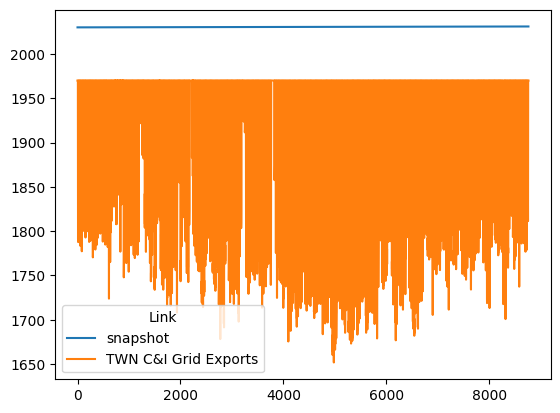

In [28]:
export_revenue.plot()

In [29]:
export_revenue = pd.melt(
    export_revenue,
    id_vars='snapshot',
    var_name='Link', 
    value_name='Value'
)

In [35]:
interconnector_lookup = (n
                            .links
                            .reset_index()[['Link', 'bus0', 'bus1']]
                            .rename(
                                columns={'bus0': 'Node', 'bus1': 'Node_Destination'})
                        )

In [36]:
export_revenue = pd.merge(
    export_revenue,
    interconnector_lookup,
    on='Link',
    how='left'
).rename(
    columns={'Node': 'Node_Destination', 'Node_Destination': 'Node'}
)

In [41]:
hourly_df = wrangle.transform_visualiser_hourly_output(n)

In [43]:
yearly_df = wrangle.transform_visualiser_yearly_output(n)

In [50]:
yearly_df[['Metric']].value_counts()

Metric                    
Transmission                  292
Revenue                       292
Curtailment                   292
Energy Balance                292
Withdrawal                    292
Installed Capacity            292
Capital Expenditure           292
Supply                        292
Operational Expenditure       292
Optimal Capacity              292
Capacity Factor               282
Expanded Capacity             259
Market Value                  229
p_nom_max                       8
Newbuild Constraints Ratio      6
capex                           6
export_revenue                  6
export_unit_cost                6
import_cost                     6
import_unit_cost                6
opex                            6
ppa_unit_cost                   6
unit_cost_all_energy            6
unit_cost_ci_energy             6
Name: count, dtype: int64

In [56]:
yearly_df[yearly_df['Metric'] == 'Newbuild Constraints Ratio']

,Type,Bus,Name,Tech,Vintage,Metric,Value,BusType,Market,Pypsa_Run_Id,Scenario,Year
3698,Generator,JPN09 C&I Grid,NaN,onshorewind-unspecified,NaN,Newbuild Constraints Ratio,0.0,Greenfield,Unspecified,Unspecified,Unspecified,2030
3699,Generator,JPN09 C&I Grid,NaN,solar-unspecified,NaN,Newbuild Constraints Ratio,0.0,Greenfield,Unspecified,Unspecified,Unspecified,2030
3700,Link,JPN09,NaN,,NaN,Newbuild Constraints Ratio,inf,Brownfield,Unspecified,Unspecified,Unspecified,2030
3701,Link,JPN09 C&I Grid,NaN,,NaN,Newbuild Constraints Ratio,inf,Greenfield,Unspecified,Unspecified,Unspecified,2030
3702,Link,JPN09 C&I Storage,NaN,,NaN,Newbuild Constraints Ratio,inf,Greenfield,Unspecified,Unspecified,Unspecified,2030
3703,StorageUnit,JPN09 C&I Storage,NaN,,NaN,Newbuild Constraints Ratio,inf,Greenfield,Unspecified,Unspecified,Unspecified,2030


<Axes: xlabel='snapshot'>

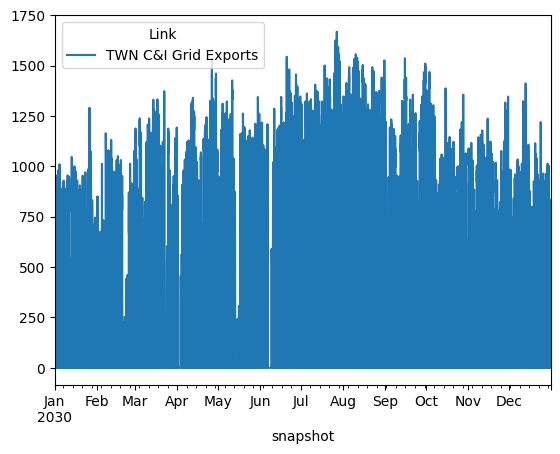

In [11]:
n.links_t.p0[['TWN C&I Grid Exports']].plot()

In [14]:
n.links_t.p0.groupby([n.links]).sum()

AttributeError: 'DataFrame' object has no attribute 'bus0'

In [18]:
n.links

,bus0,bus1,type,carrier,efficiency,active,build_year,lifetime,p_nom,p_nom_mod,...,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down,p_nom_opt,min_utilisation_rate,Unnamed: 25,max_utilisation_rate
Link,,,,,,,,,,,,,,,,,,,,,
JPN05-JPN04-2030,JPN05,JPN04,,Transmission,0.97,True,2030,50.0,527.37,0.0,...,1,0,NaN,NaN,1.0,1.0,527.370000,0.5032,NaN,1.0
JPN04-JPN05-2030,JPN04,JPN05,,Transmission,0.97,True,2030,50.0,89.96,0.0,...,1,0,NaN,NaN,1.0,1.0,89.960000,0.0058,NaN,1.0
JPN06-JPN04-2030,JPN06,JPN04,,Transmission,0.97,True,2030,50.0,3036.96,0.0,...,1,0,NaN,NaN,1.0,1.0,3036.960000,0.8000,NaN,1.0
JPN04-JPN06-2030,JPN04,JPN06,,Transmission,0.97,True,2030,50.0,3010.04,0.0,...,1,0,NaN,NaN,1.0,1.0,3010.040000,0.0219,NaN,1.0
JPN09-JPN07-2030,JPN09,JPN07,,Transmission,0.97,True,2030,50.0,2780.00,0.0,...,1,0,NaN,NaN,1.0,1.0,2780.000000,0.8000,NaN,1.0
JPN07-JPN09-2030,JPN07,JPN09,,Transmission,0.97,True,2030,50.0,620.00,0.0,...,1,0,NaN,NaN,1.0,1.0,620.000000,0.0096,NaN,1.0
JPN08-JPN07-2030,JPN08,JPN07,,Transmission,0.97,True,2030,50.0,1200.00,0.0,...,1,0,NaN,NaN,1.0,1.0,1200.000000,0.2307,NaN,1.0
JPN07-JPN08-2030,JPN07,JPN08,,Transmission,0.97,True,2030,50.0,1200.00,0.0,...,1,0,NaN,NaN,1.0,1.0,1200.000000,0.0132,NaN,1.0
JPN02-JPN01-2030,JPN02,JPN01,,Transmission,0.97,True,2030,50.0,1200.00,0.0,...,1,0,NaN,NaN,1.0,1.0,1200.000000,0.0983,NaN,1.0


In [17]:
df = n.statistics(groupby='name').reset_index()
df[df['level_0'] == 'Link']

,level_0,level_1,Optimal Capacity,Installed Capacity,Supply,Withdrawal,Energy Balance,Transmission,Capacity Factor,Curtailment,Capital Expenditure,Operational Expenditure,Revenue,Market Value
194,Link,JPN01-JPN02-2030,1000.00000,1000.00,1.993516e+06,2.055171e+06,-61655.13534,2.055171e+06,2.346086e-01,0.0,0.00000,0.00000,3.285469e+05,0.164808
195,Link,JPN02-JPN01-2030,1200.00000,1200.00,2.385323e+01,2.459095e+01,-0.73773,2.459095e+01,2.341667e-06,0.0,0.00000,0.00000,-8.859419e+01,-3.716912
196,Link,JPN02-JPN03-2030,8300.00000,8300.00,7.937689e+06,8.183185e+06,-245495.54057,8.183185e+06,1.125486e-01,0.0,0.00000,0.00000,-6.538723e+01,-0.000008
197,Link,JPN03 C&I Grid Exports,7088.18462,0.00,2.525242e+06,2.525242e+06,0.00000,2.525242e+06,4.066904e-02,0.0,70.88185,25252.42017,1.860001e+11,73656.363356
198,Link,JPN03 C&I Grid Imports,6698.84774,2575.00,2.677000e-02,2.677000e-02,0.00000,2.677000e-02,0.000000e+00,0.0,66.98848,0.00027,-1.519953e+02,NaN
199,Link,JPN03 C&I Storage Charge,7073.72451,0.00,2.877344e+06,2.877344e+06,0.00000,2.877344e+06,4.643438e-02,0.0,70.73725,28773.44430,2.075534e+11,72133.677746
200,Link,JPN03 C&I Storage Discharge,7032.55501,0.00,2.741576e+06,2.741576e+06,0.00000,2.741576e+06,4.450236e-02,0.0,70.32555,27415.76069,-1.932401e+11,-70485.035788
201,Link,JPN03-JPN02-2030,6310.00000,6310.00,4.559655e+01,4.700676e+01,-1.41020,4.700676e+01,8.510301e-07,0.0,0.00000,0.00000,-1.470025e+02,-3.220729
202,Link,JPN03-JPN04-2030,3000.00000,3000.00,4.793958e+01,4.942225e+01,-1.48267,4.942225e+01,1.880000e-06,0.0,0.00000,0.00000,-9.521698e+01,-1.987203
203,Link,JPN04-JPN03-2030,3000.00000,3000.00,1.362018e+05,1.404142e+05,-4212.42678,1.404142e+05,5.343007e-03,0.0,0.00000,0.00000,2.699747e+04,0.198217


In [120]:
# emissions_1 = (
#     (
#         n_1.generators_t.p 
#         / n_1.generators.efficiency 
#         * n_1.generators.carrier.map(n_1.carriers.co2_emissions)
#     )
# )

# emissions_2 = (
#     (
#         n_2.generators_t.p 
#         / n_2.generators.efficiency 
#         * n_2.generators.carrier.map(n_2.carriers.co2_emissions)
#     )
# )

In [139]:
# Get statistics and filter for C&I in level_1
stats = (
    n.statistics(groupby=['bus'])
    .reset_index()
    .loc[lambda df: df['level_1'].str.contains('C&I', na=False)]
)


In [122]:
emissions_1.sum().sum()

1685102364.0465403

In [137]:
stat = n.statistics(groupby=['bus']).reset_index()['level_1'].str.contains('C&I')

In [158]:
def get_ci_cost_summary(n : pypsa.Network) -> pd.DataFrame:
    '''Returns a summary of the costs for C&I generators, storage units and links
    '''
    ci_generator_costs = (
        n.generators.loc[
            n.generators.index.str.contains('C&I')
        ]
        [['carrier','p_nom','p_nom_opt','capital_cost','marginal_cost']]
        #.reset_index()
    )

    ci_generator_p_max_pu = (
        n.generators_t.p_max_pu.transpose().loc[
            n.generators_t.p_max_pu.transpose().index.str.contains('C&I')
        ]
        .transpose()
        # [['p_max_pu']]
        #.reset_index()
    )

    ci_generator_costs['dispatch'] = n.generators_t.p[ ci_generator_costs.index ].sum()
    ci_generator_costs['potential_dispatch'] = (
        ci_generator_costs.p_nom_opt[ ci_generator_costs.index ] 
        * ci_generator_p_max_pu[ ci_generator_costs.index ] 
        ).sum()
    ci_generator_costs['curtailment'] = ci_generator_costs['potential_dispatch'] - ci_generator_costs['dispatch']
    ci_generator_costs['curtailment_perc'] = ci_generator_costs['curtailment']/ci_generator_costs['potential_dispatch']

    # storage
    ci_storage_costs = (
        n.storage_units.loc[
            n.storage_units.index.str.contains('C&I')
        ]
        [['carrier','p_nom','p_nom_opt','capital_cost','marginal_cost']]
        #.reset_index()
    )

    # ci_storage_costs['dispatch'] = n.storage_units_t.p_dispatch[ ci_storage_costs.index ].sum()

    # links
    ci_links_costs = (
        n.links.loc[
            n.links.index.str.contains('C&I')
        ]
        [['carrier','p_nom','p_nom_opt','capital_cost','marginal_cost']]
        #.reset_index()
    )

    # zero link costs because they are virtual
    ci_links_costs['capital_cost'] = 0
    ci_links_costs['marginal_cost'] = 0

    ci_links_costs['dispatch'] = n.links_t.p0[ ci_links_costs.index ].sum()

    df = pd.concat([ci_generator_costs, ci_storage_costs, ci_links_costs]).round(3)

    df.loc[:, 'capex'] = df['p_nom_opt'] * df['capital_cost']
    df.loc[:, 'opex'] = df['dispatch'] * df['marginal_cost']

    # calculate import costs
    import_links_t = n.links_t.p0.filter(regex='C&I').filter(regex='Import').sum(axis=1)
    import_link_p = n.buses_t.marginal_price.filter(regex='^(?!.*C&I)').mean(axis=1)
    import_cost = ( import_links_t * import_link_p ).sum() 

    # append to df
    df.loc[ df.index.str.contains('Import'), 'import_cost' ] = import_cost

    # calculate export revenues
    export_links_t = n.links_t.p0.filter(regex='C&I').filter(regex='Export').sum(axis=1)
    export_link_p = n.buses_t.marginal_price.filter(regex='^(?!.*C&I)').mean(axis=1)
    export_revenue = -( export_links_t * export_link_p ).sum().sum()

    # append to df
    df.loc[ df.index.str.contains('Export'), 'export_revenue' ] = export_revenue

    # fillna
    df.fillna(0, inplace=True)

    return df

In [163]:
cost_summary = get_ci_cost_summary(n)

In [164]:
unit_cost_denominator = (
    cost_summary[cost_summary.index.str.contains('Grid Imports|Grid Exports')]
    .assign(ci_load = n.loads_t.p.filter(regex='C&I').sum().sum())
    .loc[:, ['dispatch', 'ci_load']]
    .reset_index()
    .assign(
        Node=lambda df: df['index'].str.split('C&I').str[0].str.strip(),  # Gets "JPN08"
    )
    .rename(columns={'index': 'flow'})
    .pivot_table(index=['Node', 'ci_load'], columns='flow', values='dispatch')
    .reset_index()
    .rename(columns=lambda x: 'grid_exports' if 'Grid Exports' in str(x) else x)
    .rename(columns=lambda x: 'grid_imports' if 'Grid Imports' in str(x) else x)
    .rename_axis(columns=None)
    .assign(ppa_weighting=lambda df: (df['ci_load'] - df['grid_imports'])/df['ci_load'])
    .assign(import_weighting=lambda df: df['grid_imports'] / df['ci_load'])
)

In [165]:
unit_cost = (
    cost_summary[~cost_summary.index.str.contains('Charge|Discharge')]
    .assign(carrier=lambda df: df['carrier'].where(~df.index.str.contains('Grid Exports'), 'Grid Exports'))
    .assign(carrier=lambda df: df['carrier'].where(~df.index.str.contains('Grid Imports'), 'Grid Imports'))
    .assign(total_costs=lambda df: df[['capex', 'opex', 'import_cost', 'export_revenue']].sum(axis=1))
    .reset_index()
    .assign(
        Node=lambda df: df['index'].str.split('C&I').str[0].str.strip(),  # Gets "JPN08"
    )
    .merge(unit_cost_denominator, left_on = ['Node'], right_on = ['Node'])
    .assign(
        import_unit_cost=lambda df: np.where(
            df['carrier'] == 'Grid Imports',
            df['import_weighting'] * (1/df['grid_imports']) * df['import_cost'],
            0
        ),
        ppa_unit_cost=lambda df: np.where(
            df['carrier'] != 'Grid Imports',
            (1/(df['ci_load'] - df['grid_imports'] + df['grid_exports'])) * df['ppa_weighting'] * df['total_costs'],
            0
        ),
        export_unit_cost=lambda df: np.where(
            df['carrier'] == 'Grid Exports',
            (1/(df['ci_load'] - df['grid_imports'] + df['grid_exports'])) * df['ppa_weighting'] * df['export_revenue'],
            0
        )
    )
    .fillna(0)
    .assign(unit_cost_a=lambda df: df['ppa_unit_cost'] + df['import_unit_cost'] + df['export_unit_cost'])
)

In [190]:
hourly_df = wrangle.transform_visualiser_hourly_output(n)
yearly_df = wrangle.transform_visualiser_yearly_output(n)

In [193]:
n.links_t.p0

Link,JPN01-JPN02-2030,JPN02-JPN01-2030,JPN02-JPN03-2030,JPN03 C&I Grid Exports,JPN03 C&I Grid Imports,JPN03 C&I Storage Charge,JPN03 C&I Storage Discharge,JPN03-JPN02-2030,JPN03-JPN04-2030,JPN04-JPN03-2030,...,JPN06-JPN04-2030,JPN06-JPN05-2030,JPN06-JPN07-2030,JPN06-JPN08-2030,JPN07-JPN06-2030,JPN07-JPN08-2030,JPN07-JPN09-2030,JPN08-JPN06-2030,JPN08-JPN07-2030,JPN09-JPN07-2030
snapshot,,,,,,,,,,,,,,,,,,,,,
2030-01-01 00:00:00,70.898870,0.004387,0.009614,0.216006,1.446370e-07,0.955566,403.686022,0.007407,0.005399,0.007300,...,0.006029,0.004238,0.003613,0.0,1300.928036,0.004940,0.004209,774.173410,0.005388,0.007757
2030-01-01 01:00:00,44.076291,0.003972,0.009406,0.210488,1.460998e-07,0.949984,276.884326,0.007546,0.005470,0.007239,...,0.006042,0.004214,0.003567,0.0,1347.723699,0.005014,0.004269,750.699548,0.005306,0.007662
2030-01-01 02:00:00,6.205268,0.003586,0.009226,0.203383,1.458145e-07,0.958574,220.146525,0.007719,0.005540,0.007142,...,0.006038,0.004268,0.003615,0.0,1197.590227,0.005061,0.004211,716.586185,0.005254,0.007824
2030-01-01 03:00:00,8.434196,0.003405,0.009090,0.199428,1.453907e-07,0.953794,119.269720,0.007891,0.005580,0.007090,...,0.006058,0.004189,0.003669,0.0,1124.572087,0.005114,0.004200,694.948396,0.005207,0.007835
2030-01-01 04:00:00,25.949586,0.003279,0.008973,0.197581,1.449820e-07,0.968466,110.639180,0.008018,0.005604,0.007051,...,0.006046,0.004186,0.003685,0.0,1120.150641,0.005145,0.004170,692.245309,0.005188,0.007870
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2030-12-31 19:00:00,71.523015,0.002753,868.602071,0.199353,1.428186e-07,0.886621,126.302834,0.004448,0.005580,0.006964,...,0.005799,0.004072,0.003584,0.0,1450.434762,0.005239,0.004020,816.278187,0.005088,0.008149
2030-12-31 20:00:00,70.171724,0.002784,1114.950303,0.201433,1.431959e-07,0.878814,126.292226,0.004469,0.005600,0.006948,...,0.005878,0.004068,0.003573,0.0,1601.644372,0.005278,0.004042,788.959276,0.005053,0.008105
2030-12-31 21:00:00,68.412774,0.002820,1300.989505,0.203424,1.434585e-07,0.866176,73.094108,0.004508,0.005624,0.006923,...,0.006085,0.004081,0.003561,0.0,1748.340112,0.005310,0.004055,770.257871,0.005033,0.008087


In [ ]:
generator_helper = unit_cost[~unit_cost['index'].str.contains('Imports|Exports')][['Node', 'capex', 'opex', 'dispatch', 'curtailment']].groupby('Node').sum()
link_helper = unit_cost_denominator[['ci_load', 'grid_imports', 'grid_exports', 'Node']]
im_ex_helper = unit_cost[unit_cost['index'].str.contains('Imports|Exports')][['Node', 'import_cost', 'export_revenue']].groupby('Node').sum()

merged_helper = generator_helper.merge(link_helper, on='Node', how='left').merge(im_ex_helper, on='Node', how='left')

merged_helper['Unit Cost (All Energy)'] = ( 
    merged_helper['capex'] 
    + merged_helper['opex'] 
    + merged_helper['import_cost'] 
    + merged_helper['export_revenue']
    )/(
    merged_helper['ci_load'] + 
    merged_helper['grid_exports'] + 
    merged_helper['curtailment']
)

merged_helper['Unit Cost (C&I Energy only)'] = (
    merged_helper['capex'] 
    + merged_helper['opex'] 
    + merged_helper['import_cost'] 
    + merged_helper['export_revenue']
    )/merged_helper['ci_load']

In [187]:
merged_helper = pd.melt(
    merged_helper,
    id_vars=['Node'],
    var_name='Metric',
    value_name='Value'
)

In [188]:
merged_helper

,Node,Metric,Value
0,JPN03,capex,5.653338e+09
1,JPN03,opex,0.000000e+00
2,JPN03,dispatch,1.528722e+07
3,JPN03,curtailment,4.357356e+06
4,JPN03,ci_load,1.262621e+07
5,JPN03,grid_imports,2.700000e-02
6,JPN03,grid_exports,2.525242e+06
7,JPN03,import_cost,1.656216e+00
8,JPN03,export_revenue,-1.536251e+08
9,JPN03,Unit Cost (All Energy),2.819092e+02


In [178]:
unit_cost[['import_cost', 'export_revenue']]

,import_cost,export_revenue
0,0.000000,0.000000e+00
1,0.000000,0.000000e+00
2,0.000000,0.000000e+00
3,1.656216,0.000000e+00
4,0.000000,-1.536251e+08


In [174]:
unit_cost.columns

Index(['index', 'carrier', 'p_nom', 'p_nom_opt', 'capital_cost',
       'marginal_cost', 'dispatch', 'potential_dispatch', 'curtailment',
       'curtailment_perc', 'capex', 'opex', 'import_cost', 'export_revenue',
       'total_costs', 'Node', 'ci_load', 'grid_exports', 'grid_imports',
       'ppa_weighting', 'import_weighting', 'import_unit_cost',
       'ppa_unit_cost', 'export_unit_cost', 'unit_cost_a'],
      dtype='object')

In [170]:
merged_helper = generator_helper.merge(link_helper, on='Node', how='left')

In [171]:
merged_helper

,Node,capex,opex,dispatch,curtailment,ci_load,grid_imports,grid_exports
0,JPN03,5.653338e+09,0.0,1.528722e+07,4357355.787,12626210.08,0.027,2525242.017


In [ ]:
# Calculate system-wide unit costs
merged_helper['Unit Cost (All Energy)'] = ( 
    merged_helper['capex'] 
    + merged_helper['opex'] 
    + merged_helper['grid_imports'] 
    - merged_helper['grid_exports']
    )/(
    merged_helper['ci_load'] + 
    merged_helper['grid_exports'] + 
    merged_helper['curtailment']
)


In [152]:
unit_cost.set

,index,carrier,p_nom,p_nom_opt,capital_cost,marginal_cost,dispatch,potential_dispatch,curtailment,curtailment_perc,...,Node,ci_load,grid_exports,grid_imports,ppa_weighting,import_weighting,import_unit_cost,ppa_unit_cost,export_unit_cost,unit_cost_a
0,JPN03 C&I Grid-solar-unspecified-ext-2030-PPA,SolarGrid,0.0,8733.498,178613.000,0.0,9656528.130,1.250392e+07,2847395.704,0.228,...,JPN03,12626210.08,2525242.017,0.027,1.0,2.138409e-09,0.000000e+00,102.954903,0.000000,1.029549e+02
1,JPN03 C&I Grid-onshorewind-unspecified-ext-203...,OnshoreWind,0.0,3472.767,351782.000,0.0,5630692.303,7.140652e+06,1509960.083,0.211,...,JPN03,12626210.08,2525242.017,0.027,1.0,2.138409e-09,0.000000e+00,80.629692,0.000000,8.062969e+01
2,JPN03 C&I Grid-Batteries,Batteries,0.0,9893.126,290278.849,0.0,4389843.695,0.000000e+00,0.000,0.000,...,JPN03,12626210.08,2525242.017,0.027,1.0,2.138409e-09,0.000000e+00,189.537294,0.000000,1.895373e+02
3,JPN03 C&I Grid Imports,Grid Imports,2575.0,6698.848,0.000,0.0,0.027,0.000000e+00,0.000,0.000,...,JPN03,12626210.08,2525242.017,0.027,1.0,2.138409e-09,1.311729e-07,0.000000,0.000000,1.311729e-07
4,JPN03 C&I Grid Exports,Grid Exports,0.0,7088.185,0.000,0.0,2525242.017,0.000000e+00,0.000,0.000,...,JPN03,12626210.08,2525242.017,0.027,1.0,2.138409e-09,0.000000e+00,-10.139302,-10.139302,-2.027860e+01


In [151]:
unit_cost[['Node', 'capex', 'opex', 'dispatch', 'curtailment']]

,Node,capex,opex,dispatch,curtailment
0,JPN03,1.559916e+09,0.0,9656528.130,2847395.704
1,JPN03,1.221657e+09,0.0,5630692.303,1509960.083
2,JPN03,2.871765e+09,0.0,4389843.695,0.000
3,JPN03,0.000000e+00,0.0,0.027,0.000
4,JPN03,0.000000e+00,0.0,2525242.017,0.000


In [ ]:
# Get both individual prices and average grid price in one DataFrame
prices = (
    n
    .buses_t
    .marginal_price
    .filter(regex='^(?!.*C&I)')
    .reset_index()
).assign(grid_price = lambda df: df.iloc[:, 1:].mean(axis=1))  # Calculate mean of all price columns except 'snapshot'

# Initialize the DataFrame with all C&I related data
ci_data = pd.DataFrame(index=n.loads_t.p.index)

# Load
ci_data['C&I Load'] = n.loads_t.p.filter(regex='C&I').sum(axis=1)

# Import/Export volumes
import_volume = n.links_t.p0.filter(regex='C&I').filter(regex='Import')
export_volume = n.links_t.p0.filter(regex='C&I').filter(regex='Export')

# Calculate costs while maintaining DataFrame structure
# Use the grid_price column from prices DataFrame
import_costs = import_volume.mul(prices['grid_price'], axis=0)
export_revenue = -export_volume.mul(prices['grid_price'], axis=0)

# Store both detailed and total values
ci_data['C&I Import Volume'] = import_volume.sum(axis=1)
ci_data['C&I Export Volume'] = export_volume.sum(axis=1)

# Store individual import/export costs by link
for col in import_costs.columns:
    link_name = col.replace('Import', 'Import Cost')
    ci_data[link_name] = import_costs[col]

for col in export_revenue.columns:
    link_name = col.replace('Export', 'Export Revenue')
    ci_data[link_name] = export_revenue[col]

# Store totals
ci_data['C&I Import Cost Total'] = import_costs.sum(axis=1)
ci_data['C&I Export Revenue Total'] = export_revenue.sum(axis=1)


In [ ]:
# Get average grid price (calculated once to avoid repetition)
grid_price = n.buses_t.marginal_price.filter(regex='^(?!.*C&I)').mean(axis=1)

# Initialize the DataFrame with all C&I related data
ci_data = pd.DataFrame(index=n.loads_t.p.index)

# Load
ci_data['C&I Load'] = n.loads_t.p.filter(regex='C&I').sum(axis=1)

# C&I Price
ci_data['C&I Price'] = grid_price

# Import/Export volumes and costs
ci_data['C&I Import Volume'] = n.links_t.p0.filter(regex='C&I').filter(regex='Import').sum(axis=1)
ci_data['C&I Export Volume'] = n.links_t.p0.filter(regex='C&I').filter(regex='Export').sum(axis=1)
ci_data['C&I Import Cost'] = ci_data['C&I Import Volume'] * grid_price
ci_data['C&I Export Revenue'] = -ci_data['C&I Export Volume'] * grid_price  # Negative because exports generate revenue

# Group generators by technology type
ci_generators = n.generators[n.generators.index.str.contains('C&I')]
tech_groups = ci_generators.groupby('carrier')

# Generation and Curtailment by technology
for tech, group in tech_groups:
    tech_name = f'C&I {tech}'

    # Generation
    ci_data[f'{tech_name} Generation'] = n.generators_t.p[group.index].sum(axis=1)

    # Potential Generation
    ci_data[f'{tech_name} Potential'] = (
        n.generators_t.p_max_pu[group.index] * 
        n.generators.p_nom_opt[group.index]
    ).sum(axis=1)

    # Curtailment
    ci_data[f'{tech_name} Curtailment'] = (
        ci_data[f'{tech_name} Potential'] - 
        ci_data[f'{tech_name} Generation']
    )

    # Hourly expanded CAPEX
    yearly_capex = (
        n.generators.capital_cost[group.index] * 
        n.generators.p_nom_opt[group.index]
    ).sum()

    capex_hourly = yearly_capex / 8760
    ci_data[f'{tech_name} CAPEX'] = pd.Series([capex_hourly] * len(ci_data.index), index=ci_data.index)

    # OPEX
    ci_data[f'{tech_name} OPEX'] = (
        n.generators_t.p[group.index] * 
        group['marginal_cost'].values
    ).sum(axis=1)

    # Total cost
    ci_data[f'{tech_name} Total Cost'] = (
        ci_data[f'{tech_name} CAPEX'] + 
        ci_data[f'{tech_name} OPEX']
    )

# Sum up CAPEX and OPEX across all technologies
capex_cols = [col for col in ci_data.columns if 'CAPEX' in col]
opex_cols = [col for col in ci_data.columns if 'OPEX' in col]
curtailment_cols = [col for col in ci_data.columns if 'Curtailment' in col]

ci_data['C&I Total CAPEX'] = ci_data[capex_cols].sum(axis=1)
ci_data['C&I Total OPEX'] = ci_data[opex_cols].sum(axis=1)
ci_data['C&I Total Curtailment'] = ci_data[curtailment_cols].sum(axis=1)

# Calculate total system cost
ci_data['C&I Total Cost'] = (
    ci_data['C&I Total CAPEX'] + 
    ci_data['C&I Total OPEX'] + 
    ci_data['C&I Import Cost'] + 
    ci_data['C&I Export Revenue']
)

# Calculate system-wide unit costs
ci_data['Unit Cost (All Energy)'] = ci_data['C&I Total Cost']/(
    ci_data['C&I Load'] + 
    ci_data['C&I Export Volume'] + 
    ci_data['C&I Total Curtailment']
)

ci_data['Unit Cost (C&I Energy only)'] = ci_data['C&I Total Cost']/ci_data['C&I Load']

# Looping to calculate unit cost breakdown
for tech, group in tech_groups:
    tech_name = f'C&I {tech}'
    ci_data[f'{tech_name} Unit Cost'] = ci_data[f'{tech_name} Total Cost']/(
        ci_data['C&I Load'] + 
        ci_data['C&I Export Volume'] + 
        ci_data['C&I Total Curtailment']
        )

In [141]:
# Get average grid price (calculated once to avoid repetition)
grid_price = n.buses_t.marginal_price.filter(regex='^(?!.*C&I)').mean(axis=1)

# Initialize the DataFrame with all C&I related data
ci_data = pd.DataFrame(index=n.loads_t.p.index)

# Load
ci_data['C&I Load'] = n.loads_t.p.filter(regex='C&I').sum(axis=1)

# C&I Price
ci_data['C&I Price'] = grid_price

# Import/Export volumes and costs
ci_data['C&I Import Volume'] = n.links_t.p0.filter(regex='C&I').filter(regex='Import').sum(axis=1)
ci_data['C&I Export Volume'] = n.links_t.p0.filter(regex='C&I').filter(regex='Export').sum(axis=1)
ci_data['C&I Import Cost'] = ci_data['C&I Import Volume'] * grid_price
ci_data['C&I Export Revenue'] = -ci_data['C&I Export Volume'] * grid_price  # Negative because exports generate revenue

# Group generators by technology type
ci_generators = n.generators[n.generators.index.str.contains('C&I')]
tech_groups = ci_generators.groupby('carrier')

# Generation and Curtailment by technology
for tech, group in tech_groups:
    tech_name = f'C&I {tech}'

    # Generation
    ci_data[f'{tech_name} Generation'] = n.generators_t.p[group.index].sum(axis=1)

    # Potential Generation
    ci_data[f'{tech_name} Potential'] = (
        n.generators_t.p_max_pu[group.index] * 
        n.generators.p_nom_opt[group.index]
    ).sum(axis=1)

    # Curtailment
    ci_data[f'{tech_name} Curtailment'] = (
        ci_data[f'{tech_name} Potential'] - 
        ci_data[f'{tech_name} Generation']
    )

    # Hourly expanded CAPEX
    yearly_capex = (
        n.generators.capital_cost[group.index] * 
        n.generators.p_nom_opt[group.index]
    ).sum()

    capex_hourly = yearly_capex / 8760
    ci_data[f'{tech_name} CAPEX'] = pd.Series([capex_hourly] * len(ci_data.index), index=ci_data.index)

    # OPEX
    ci_data[f'{tech_name} OPEX'] = (
        n.generators_t.p[group.index] * 
        group['marginal_cost'].values
    ).sum(axis=1)

    # Total cost
    ci_data[f'{tech_name} Total Cost'] = (
        ci_data[f'{tech_name} CAPEX'] + 
        ci_data[f'{tech_name} OPEX']
    )

# Sum up CAPEX and OPEX across all technologies
capex_cols = [col for col in ci_data.columns if 'CAPEX' in col]
opex_cols = [col for col in ci_data.columns if 'OPEX' in col]
curtailment_cols = [col for col in ci_data.columns if 'Curtailment' in col]

ci_data['C&I Total CAPEX'] = ci_data[capex_cols].sum(axis=1)
ci_data['C&I Total OPEX'] = ci_data[opex_cols].sum(axis=1)
ci_data['C&I Total Curtailment'] = ci_data[curtailment_cols].sum(axis=1)

# Calculate total system cost
ci_data['C&I Total Cost'] = (
    ci_data['C&I Total CAPEX'] + 
    ci_data['C&I Total OPEX'] + 
    ci_data['C&I Import Cost'] + 
    ci_data['C&I Export Revenue']
)

# Calculate system-wide unit costs
ci_data['Unit Cost (All Energy)'] = ci_data['C&I Total Cost']/(
    ci_data['C&I Load'] + 
    ci_data['C&I Export Volume'] + 
    ci_data['C&I Total Curtailment']
)

ci_data['Unit Cost (C&I Energy only)'] = ci_data['C&I Total Cost']/ci_data['C&I Load']

# Looping to calculate unit cost breakdown
for tech, group in tech_groups:
    tech_name = f'C&I {tech}'
    ci_data[f'{tech_name} Unit Cost'] = ci_data[f'{tech_name} Total Cost']/(
        ci_data['C&I Load'] + 
        ci_data['C&I Export Volume'] + 
        ci_data['C&I Total Curtailment']
        )

In [142]:
ci_data

,C&I Load,C&I Price,C&I Import Volume,C&I Export Volume,C&I Import Cost,C&I Export Revenue,C&I OnshoreWind Generation,C&I OnshoreWind Potential,C&I OnshoreWind Curtailment,C&I OnshoreWind CAPEX,...,C&I SolarGrid OPEX,C&I SolarGrid Total Cost,C&I Total CAPEX,C&I Total OPEX,C&I Total Curtailment,C&I Total Cost,Unit Cost (All Energy),Unit Cost (C&I Energy only),C&I OnshoreWind Unit Cost,C&I SolarGrid Unit Cost
snapshot,,,,,,,,,,,,,,,,,,,,,
2030-01-01 00:00:00,1478.16,62.380776,1.446370e-07,0.216006,0.000009,-13.474641,1075.645550,1083.503452,7.857902,139458.571602,...,0.0,178072.635611,317531.207213,0.0,7.857902,317517.732581,213.639139,214.806065,93.833528,119.814677
2030-01-01 01:00:00,1385.84,62.380780,1.460998e-07,0.210488,0.000009,-13.130433,1110.116147,1118.231126,8.114979,139458.571602,...,0.0,178072.635611,317531.207213,0.0,8.114979,317518.076790,227.747770,229.115971,100.030143,127.727045
2030-01-01 02:00:00,1325.64,62.380864,1.458145e-07,0.203383,0.000009,-12.687207,1106.655432,1114.758359,8.102927,139458.571602,...,0.0,178072.635611,317531.207213,0.0,8.102927,317518.520016,238.029460,239.520926,104.545866,133.493106
2030-01-01 03:00:00,1279.92,62.380839,1.453907e-07,0.199428,0.000009,-12.440489,1161.803501,1170.322638,8.519137,139458.571602,...,0.0,178072.635611,317531.207213,0.0,8.519137,317518.766733,246.398622,248.077041,108.221634,138.186642
2030-01-01 04:00:00,1260.92,62.380790,1.449820e-07,0.197581,0.000009,-12.325263,1151.446867,1159.904336,8.457469,139458.571602,...,0.0,178072.635611,317531.207213,0.0,8.457469,317518.881960,250.098552,251.815248,109.846654,140.261606
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2030-12-31 19:00:00,1518.00,61.965191,1.428186e-07,0.199353,0.000009,-12.352958,1392.783141,1402.998059,10.214918,139458.571602,...,0.0,178072.635611,317531.207213,0.0,10.214918,317518.854264,207.743974,209.169206,91.243961,116.508095
2030-12-31 20:00:00,1490.40,61.965191,1.431959e-07,0.201433,0.000009,-12.481837,1365.188020,1375.215919,10.027899,139458.571602,...,0.0,178072.635611,317531.207213,0.0,10.027899,317518.725385,211.590377,213.042623,92.933390,118.665304
2030-12-31 21:00:00,1451.00,61.965191,1.434585e-07,0.203424,0.000009,-12.605223,1378.975492,1389.106989,10.131497,139458.571602,...,0.0,178072.635611,317531.207213,0.0,10.131497,317518.602000,217.279829,218.827431,95.432313,121.856142
